# Learning Session 5 - January 29, 2026

In [ ]:
# Installing and loading the relevant packages

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

In [2]:
# Load the 'tips' dataset from seaborn

tips = sns.load_dataset("tips")
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


<Axes: xlabel='total_bill', ylabel='tip'>

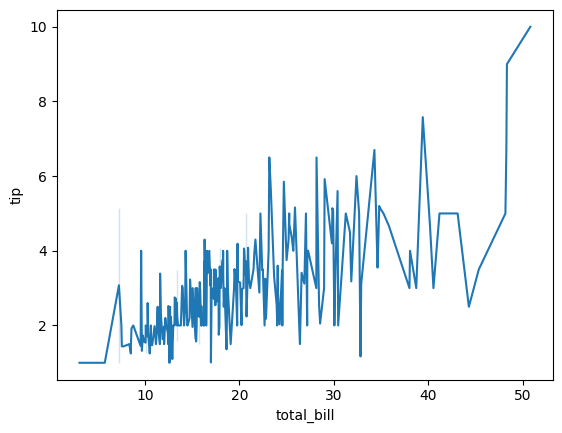

In [3]:
# Making a simple line plot of tip amount vs total bill

sns.lineplot(data=tips, # choose our dataset
x='total_bill', # define our x variable
y='tip') # define our y variable

<Axes: xlabel='total_bill', ylabel='tip'>

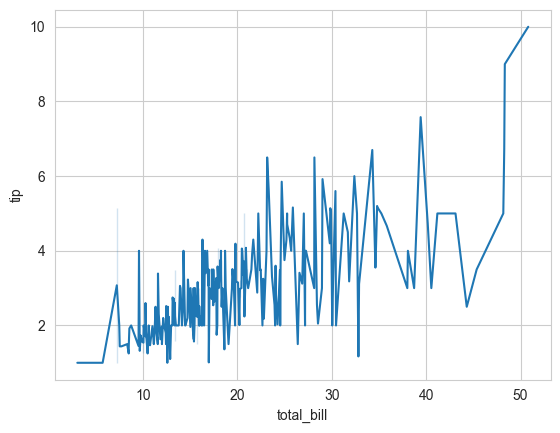

In [ ]:
# Using premade styles

# Altering the appearance of the plot using 'whitegrid'

sns.set_style('whitegrid')
sns.lineplot(data=tips,
x='total_bill',
y='tip')

<Axes: xlabel='total_bill', ylabel='tip'>

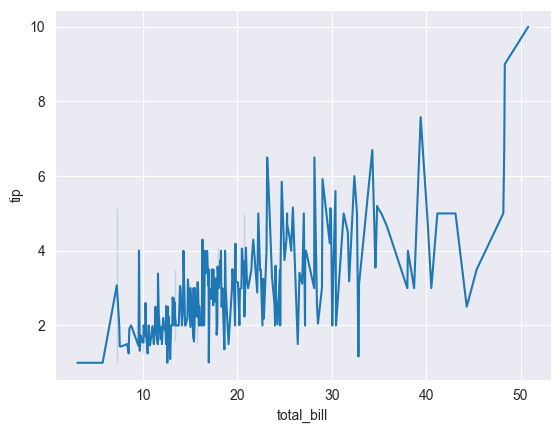

In [6]:
# Using premade styles

# Altering the appearance of the plot using 'darkgrid'

sns.set_style('darkgrid')
sns.lineplot(data=tips,
x='total_bill',
y='tip')

<Axes: xlabel='total_bill', ylabel='tip'>

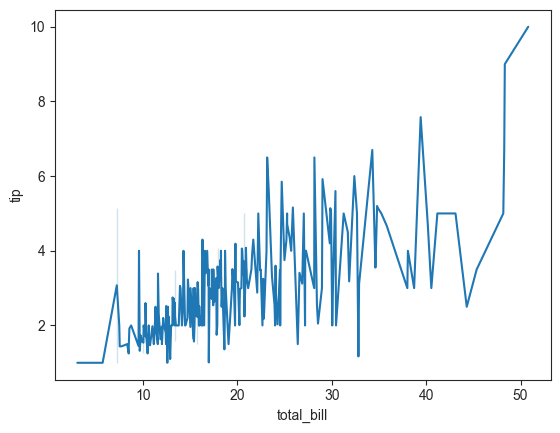

In [ ]:
# Using premade styles

# Altering the appearance of the plot using 'ticks'

sns.set_style('ticks')
sns.lineplot(data=tips,
x='total_bill',
y='tip')

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

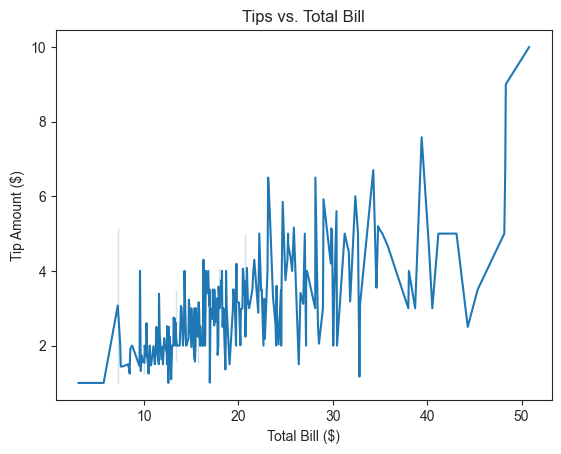

In [9]:
# Using premade styles

# Adding titles and labels

sns.set_style('ticks')
tipgraph = sns.lineplot(data=tips,
x='total_bill',
y='tip')
tipgraph.set(title='Tips vs. Total Bill',
xlabel='Total Bill ($)',
ylabel='Tip Amount ($)')

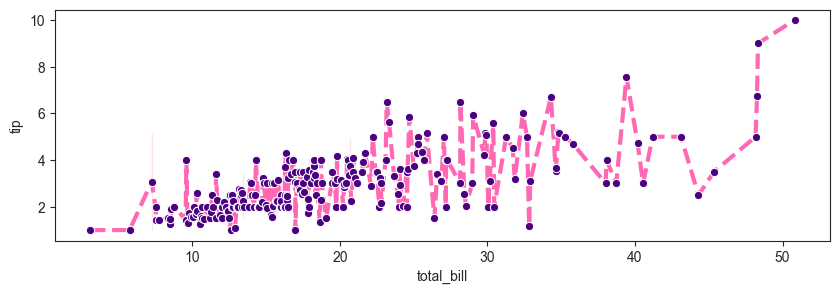

In [13]:
# Using premade styles

# Modifyin aesthetic elements, including changing color, marker style,
# and line style.

fig = plt.subplots(figsize=(10, 3))
tipgraph = sns.lineplot(data=tips,
x='total_bill',
y='tip',
color = 'hotpink',
linestyle = '--',
linewidth = 3,
marker = 'o',
markerfacecolor = 'indigo')

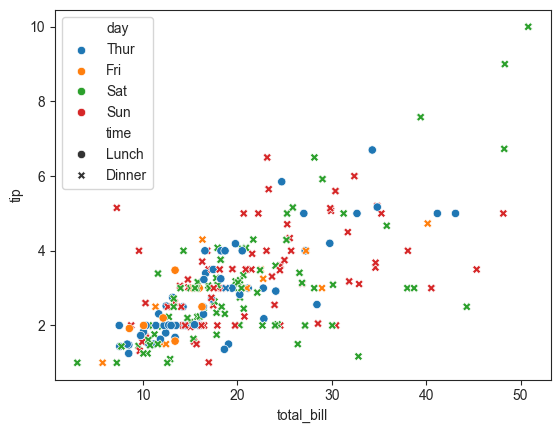

In [18]:
# Adding multiple variables

tipgraph = sns.scatterplot(data=tips,x='total_bill',
y='tip', style = 'time', hue ='day')

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

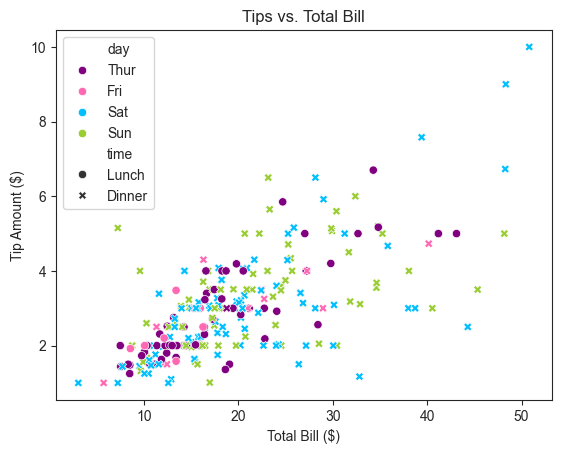

In [23]:
# Adding multiple variables

tipgraph = sns.scatterplot(data=tips,x='total_bill',
y='tip', style = 'time', hue ='day', palette=['purple', 'hotpink', 
'deepskyblue', 'yellowgreen'])

tipgraph.set(title='Tips vs. Total Bill',
xlabel='Total Bill ($)',
ylabel='Tip Amount ($)')

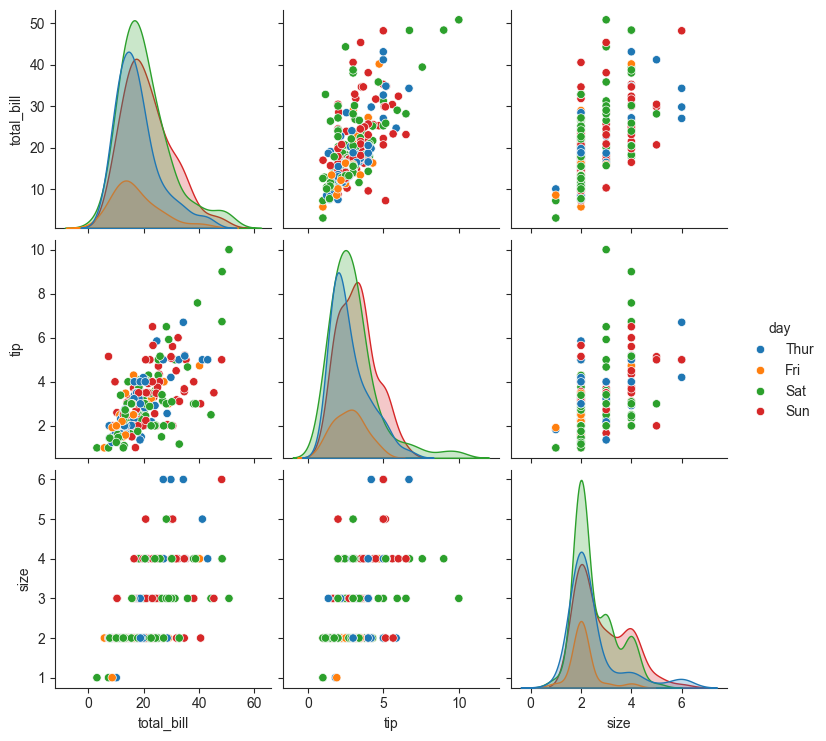

In [ ]:
# Pairplot Visualization

sns.pairplot(
data = tips,
hue = 'day')

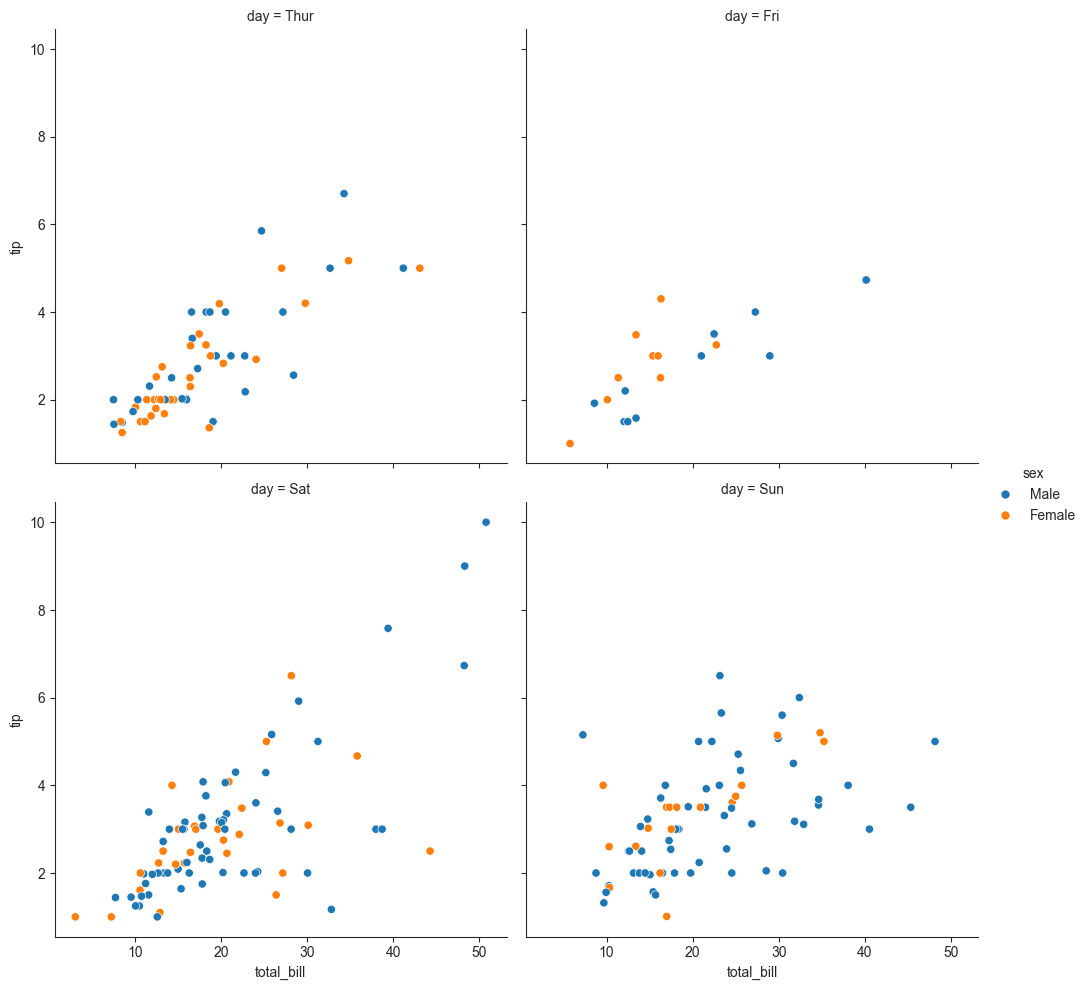

In [ ]:
# Relplot Visualization

daysplot = sns.relplot(
data=tips,
x="total_bill",
y="tip",
hue="sex",
col="day",
kind="scatter",
col_wrap=2)

In [26]:
# Plotly

import plotly.graph_objects as go # 'go' is 'graph objects’
x1 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])

In [27]:
# Making a plotly figure

graph = go.Figure()

In [28]:
# Choosing the plot type (bar) and adding data

graph.add_trace(go.Bar(x=x1, y=y1))

In [29]:
# Updating the layout to include titles

graph.update_layout(
title="Pirate Scores",
xaxis_title="Pirates",
yaxis_title="Score")

In [30]:
# Customizing plotly graphs

graph = go.Figure()
graph.add_trace(go.Scatter(x=x1, y=y1, mode='markers', marker=dict(
size=15, # point size
color='hotpink', # point colour
opacity=1, # point transparency/alpha
line=dict(width=5, color='purple') # point outline
# we want points for a scatter plot
)))

In [31]:
# Customizing plotly graphs

graph.update_layout(
title='Interactive Pirate Plot',
xaxis_title='Pirates',
yaxis_title='Scores',
width=500, height=500)

In [32]:
# Making wordclouds

# Importing the wordcloud package and loading the sample dataset of movie quotes

from wordcloud import WordCloud
df = pd.read_csv("https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv",
on_bad_lines='skip')
df

,quote,movie,type,year
0,"Do, or do not. There is no try.",Star Wars: Episode V - The Empire Strikes Back,movie,1890
1,Listen to them. Children of the night. What mu...,Dracula,movie,1931
2,It's alive! It's alive!,Frankenstein,movie,1931
3,"Oh, no, it wasn't the airplanes. It was Beauty...",King Kong,movie,1933
4,"Magic Mirror on the wall, who is the fairest o...",Snow White and the Seven Dwarves,movie,1937
...,...,...,...,...
727,I didn't know if you were lost. Stick with me....,Us,movie,2019
728,This guy's awesome! He's holding his own while...,Dragon Ball Super: Broly,movie,2019
729,"Murder is murder, it don’t matter who you are.",Black and Blue,movie,2019
730,You know what a lion is? A lion is a strong an...,Between Two Ferns: The Movie,movie,2019


(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

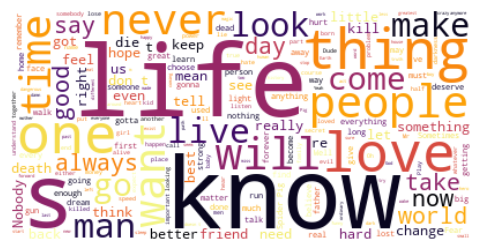

In [42]:
# Making simple word cloud using the 'quote' variable

# Joining all the text from each row from the quote column into a string
text = " ".join(each for each in df.quote)

# Generating the wordcloud image
wordcloud = WordCloud(background_color="white",
colormap = 'inferno').generate(text)

# Using matplotlib syntax to put the image in a figure
fig, ax = plt.subplots(figsize=(7, 3))
ax.imshow(wordcloud, interpolation='bilinear') 
ax.axis("off")

In [43]:
# Making venn diagrams

# Importing the package

from matplotlib_venn import venn2, venn2_circles, venn2_unweighted


In [44]:
# Making venn diagrams

# Importing the package

# Defining the sets

A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])

/Users/bukkyshonibare/Desktop/DSI/visualization/.venv/lib/python3.11/site-packages/matplotlib_venn/_util.py:32: UserWarning:

venn2_unweighted is deprecated. Use venn2 with the appropriate layout_algorithm instead.



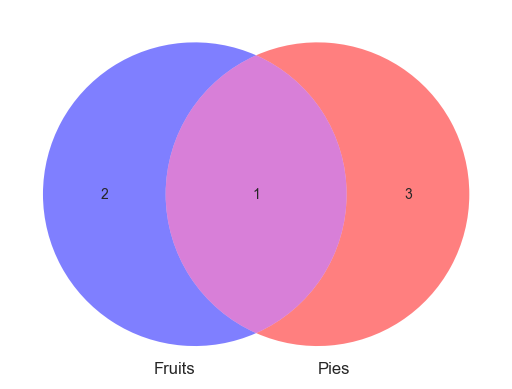

In [ ]:
# Making venn diagrams

# Assigning the sets to each circle and modifying the appearance

diagram = venn2_unweighted([A, B],
set_labels = ('Fruits', 'Pies'),
set_colors=("blue", "red"),
alpha=0.5)
plt.show()

/Users/bukkyshonibare/Desktop/DSI/visualization/.venv/lib/python3.11/site-packages/matplotlib_venn/_util.py:32: UserWarning:

venn2_unweighted is deprecated. Use venn2 with the appropriate layout_algorithm instead.



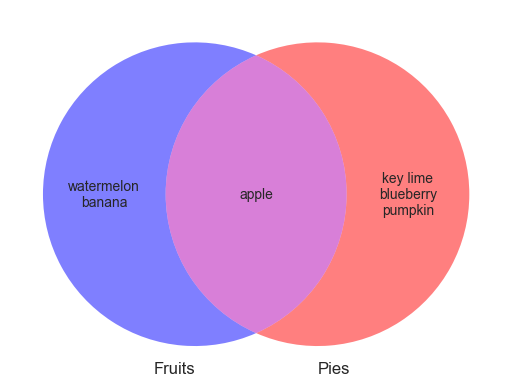

In [49]:
# Modifying venn diagrams

# Assigning the sets to each circle and modifying the appearance

diagram = venn2_unweighted([A, B],
set_labels = ('Fruits', 'Pies'),
set_colors=("blue", "red"),
alpha=0.5)

diagram.get_label_by_id("10").set_text("\n".join(A - B))
diagram.get_label_by_id("11").set_text("\n".join(A & B))
diagram.get_label_by_id("01").set_text("\n".join(B - A))